In [1]:
file_read = "001_fit"
file_write = "002_RMSE"

In [2]:
import polars as pl

df_train_val_preds = pl.read_parquet(f"{file_read}_train_val_preds.parquet")
df_test_preds = pl.read_parquet(f"{file_read}_test_preds.parquet")
df_coefs = pl.read_parquet(f"{file_read}_coefs.parquet")

In [3]:
column_target = "beta_alpha"
column_pred = f"{column_target}_pred"

In [4]:
df_train_val_rmse = (
    df_train_val_preds
    .group_by("n_features", maintain_order=True)
    .agg(
        (pl.col(column_target) - pl.col(column_pred)).pow(2).mean().sqrt()
        .alias(f"{column_target}_rmse")
    )
)

In [5]:
df_train_val_rmse

n_features,beta_alpha_rmse
i32,f64
86,0.199308
85,0.199308
84,0.199308
83,0.199308
82,0.199309
…,…
9,0.208353
8,0.212546
7,0.215221


In [6]:
df_train_val_rmse_min = df_train_val_rmse.filter(
    pl.col(f"{column_target}_rmse") == pl.col(f"{column_target}_rmse").min()
)

In [7]:
df_train_val_rmse_min

n_features,beta_alpha_rmse
i32,f64
32,0.198084


In [8]:
n_features_min = df_train_val_rmse_min["n_features"][0]

In [9]:
df_test_rmse = (
    df_test_preds
    .group_by("n_features", maintain_order=True)
    .agg(
        (pl.col(column_target) - pl.col(column_pred)).pow(2).mean().sqrt()
        .alias(f"{column_target}_rmse")
    )
)

In [10]:
df_test_rmse

n_features,beta_alpha_rmse
i32,f64
86,0.251734
85,0.251734
84,0.251734
83,0.251734
82,0.251647
…,…
9,0.316122
8,0.366891
7,0.368156


In [11]:
df_test_rmse_min = df_test_rmse.filter(pl.col("n_features") == n_features_min)

In [12]:
df_test_rmse_min

n_features,beta_alpha_rmse
i32,f64
32,0.28544


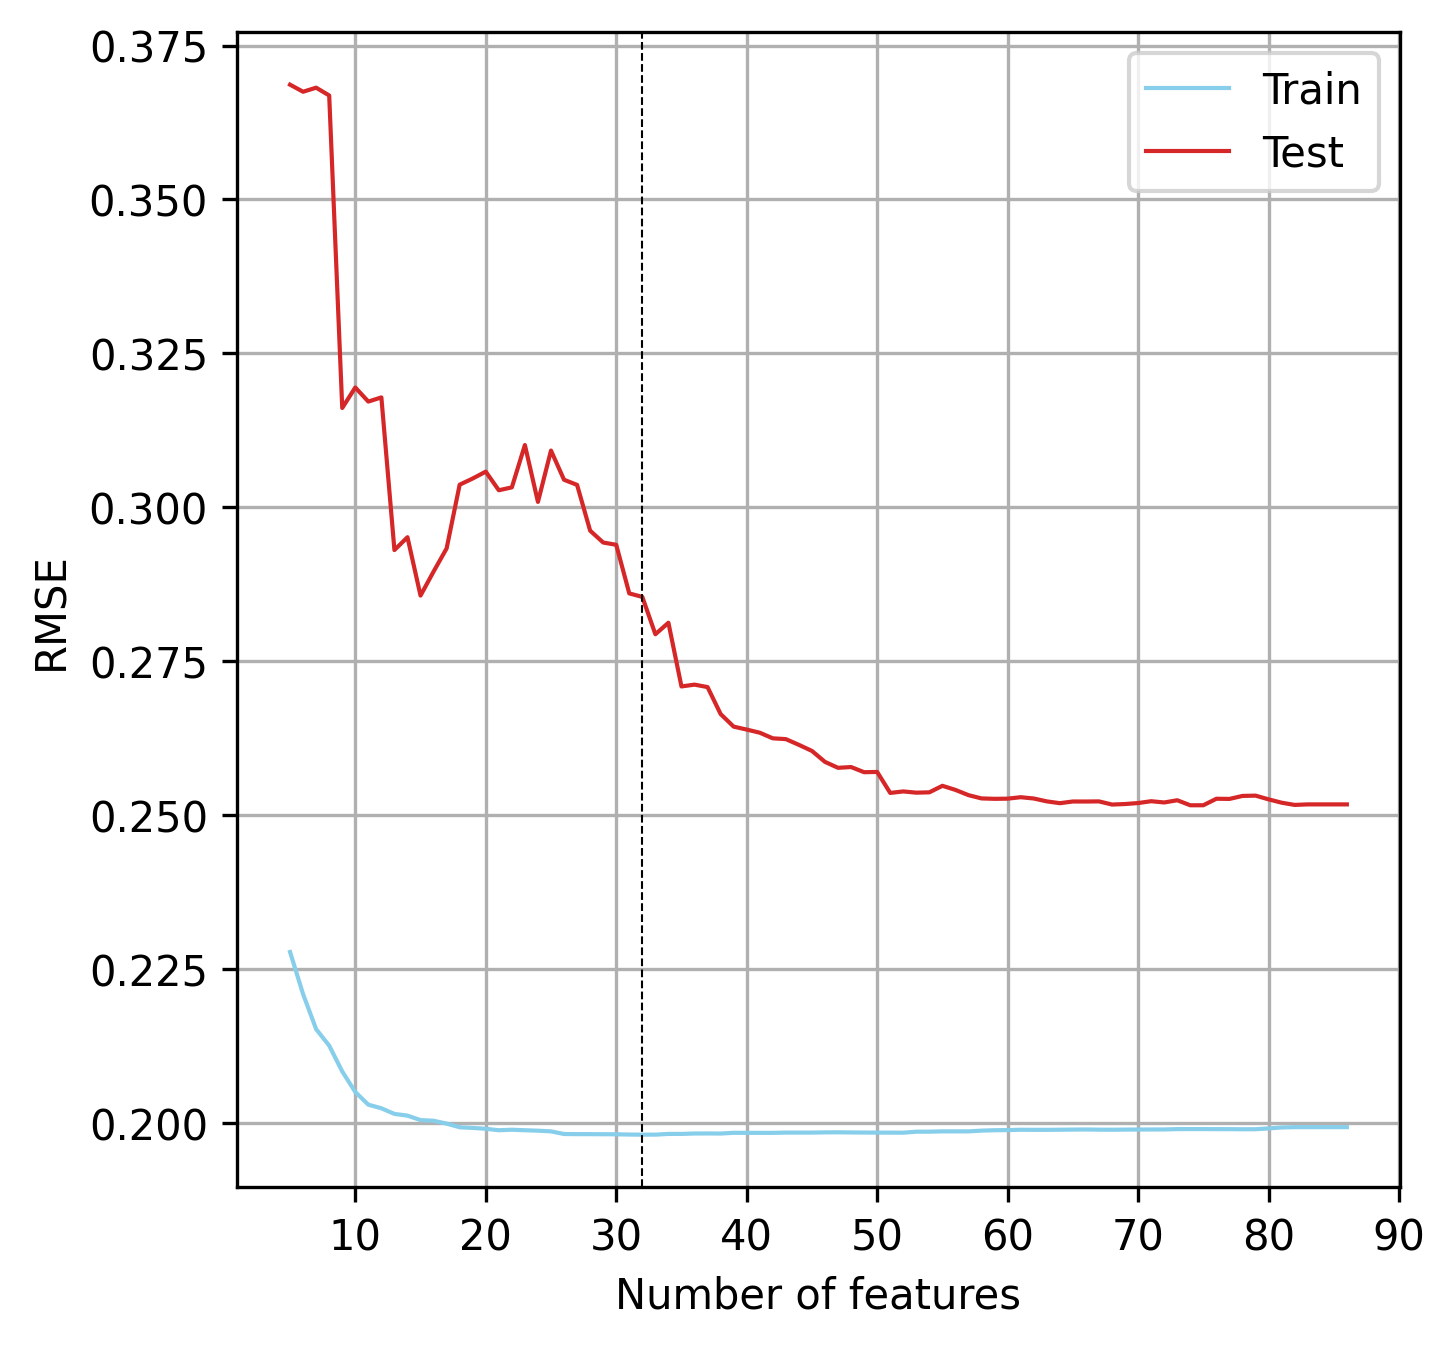

In [13]:
import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(5, 5), dpi=300)

ax.plot(
    df_train_val_rmse["n_features"],
    df_train_val_rmse[f"{column_target}_rmse"],
    c="skyblue",
    label="Train",
    lw=1
)
ax.plot(
    df_test_rmse["n_features"],
    df_test_rmse[f"{column_target}_rmse"],
    c="tab:red",
    label="Test",
    lw=1
)
ax.axvline(
    n_features_min,
    c="black",
    lw=0.5,
    ls="--"
)

ax.set_xlabel("Number of features")
ax.set_ylabel("RMSE")

ax.grid()
ax.legend()

plt.savefig(
    f"{file_write}_plot.png",
    transparent=True,
    bbox_inches="tight",
    pad_inches=0.1
)
plt.show()

In [14]:
df_train_val_min = df_train_val_preds.filter(pl.col("n_features") == n_features_min)

In [15]:
df_train_val_min

pyridone_test,n_features,pyridone,backbone,beta_alpha,beta_alpha_pred
i32,i32,i64,i64,f64,f64
0,32,1,0,2.928763,3.10552
0,32,1,1,2.982038,3.121806
0,32,1,2,3.21741,3.121592
0,32,1,3,3.161632,3.012647
0,32,1,4,3.217922,3.028029
…,…,…,…,…,…
12,32,11,3,2.003263,2.148658
12,32,11,4,2.016259,2.16154
12,32,11,5,3.974007,3.365643


In [16]:
df_test_min = df_test_preds.filter(pl.col("n_features") == n_features_min)

In [17]:
df_test_min

pyridone_test,n_features,backbone,beta_alpha,beta_alpha_pred
i32,i32,i64,f64,f64
0,32,0,2.524862,2.730724
0,32,1,2.556494,2.74701
0,32,2,2.635717,2.746796
0,32,3,2.576968,2.637852
0,32,4,2.582272,2.653233
…,…,…,…,…
12,32,3,2.554692,2.33209
12,32,4,2.587168,2.344972
12,32,5,3.729587,3.549076


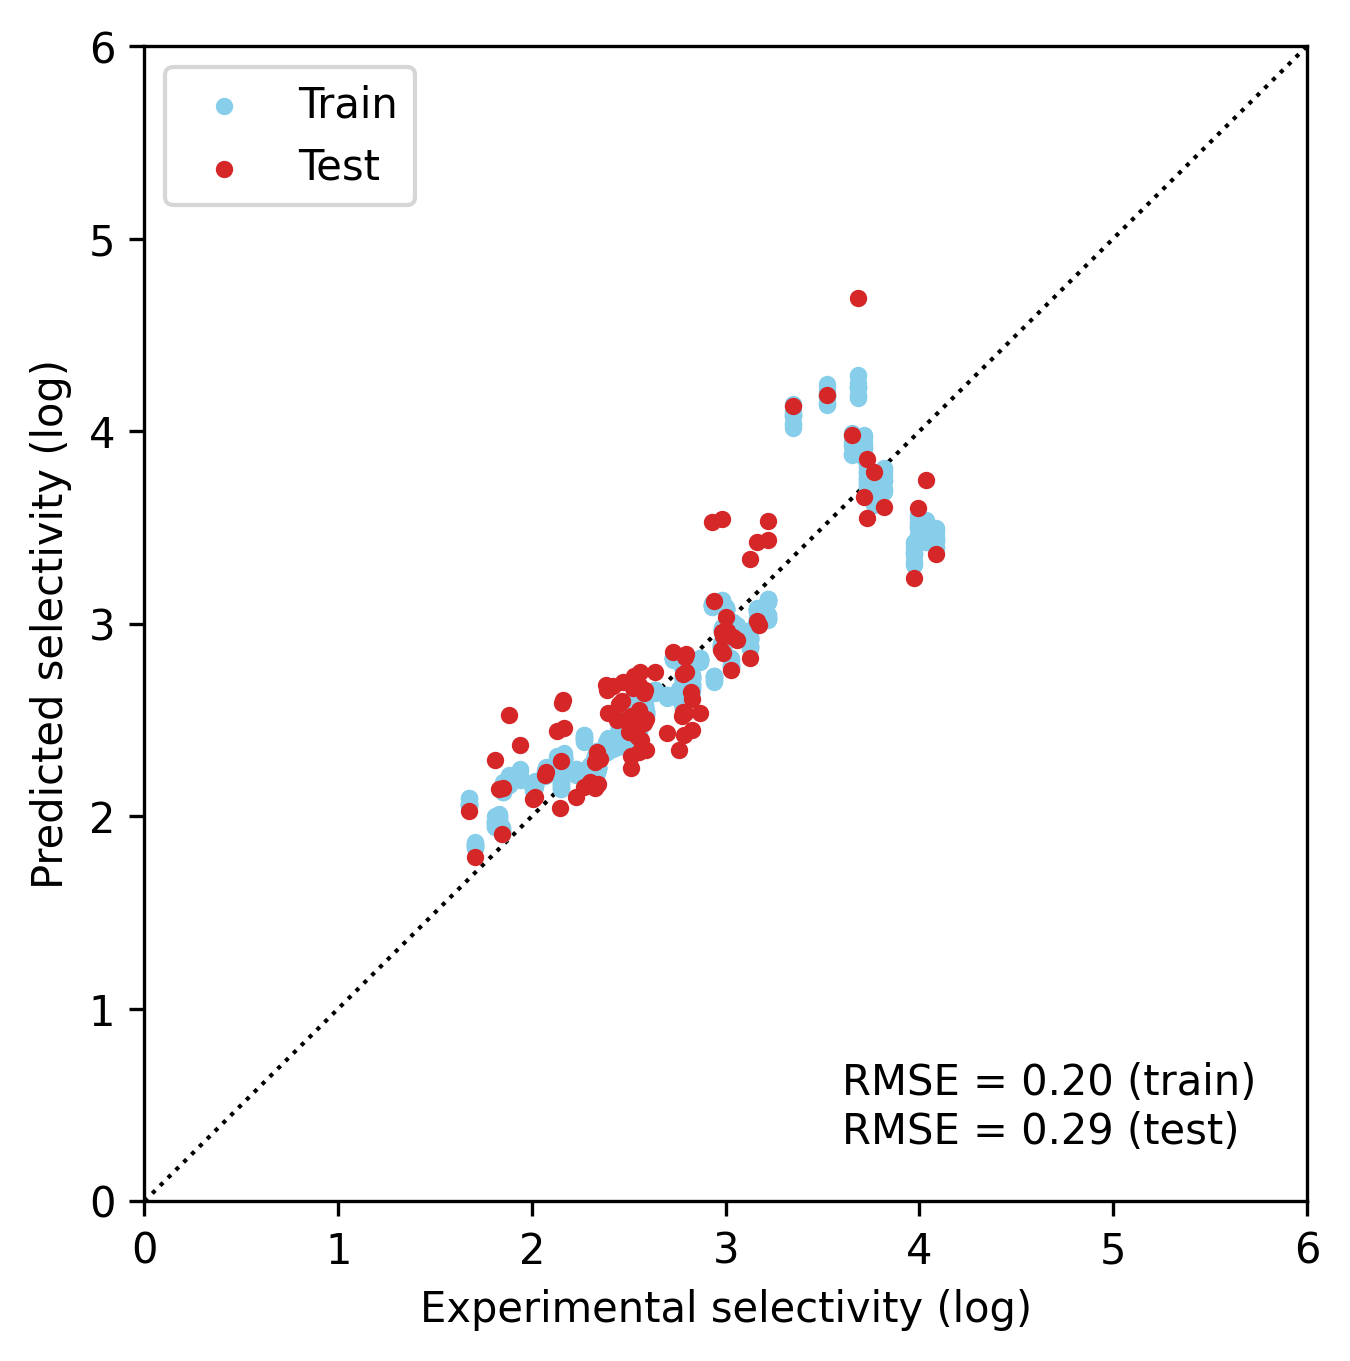

In [18]:
fig, ax = plt.subplots(figsize=(5, 5), dpi=300)

ax.plot(
    [0, 100],
    [0, 100],
    c="black",
    linestyle="dotted",
    lw=1,
    zorder=0
)
ax.scatter(
    df_train_val_min[column_target],
    df_train_val_min[column_pred],
    c="skyblue",
    label="Train",
    s=10,
    zorder=1
)
ax.scatter(
    df_test_min[column_target],
    df_test_min[column_pred],
    c="tab:red",
    label="Test",
    s=10,
    zorder=2
)

ax.set_xlabel("Experimental selectivity (log)")
ax.set_ylabel("Predicted selectivity (log)")
ax.set_xlim(0, 6)
ax.set_ylim(0, 6)

ax.legend()
ax.text(
    0.60, 0.05,
    f"RMSE = {df_train_val_rmse_min[f'{column_target}_rmse'][0]:1.2f} (train)\n"
    f"RMSE = {df_test_rmse_min[f'{column_target}_rmse'][0]:1.2f} (test)",
    transform=ax.transAxes
)

plt.savefig(
    f"{file_write}_scatter_all.png",
    transparent=True,
    bbox_inches="tight",
    pad_inches=0.1
)
plt.show()

In [19]:
column_group = "pyridone"

In [20]:
groups_test = df_test_preds[f"{column_group}_test"].unique(maintain_order=True)

In [21]:
groups_test

pyridone_test
i32
0
1
2
3
4
…
8
9
10


In [22]:
df_train_val_min

pyridone_test,n_features,pyridone,backbone,beta_alpha,beta_alpha_pred
i32,i32,i64,i64,f64,f64
0,32,1,0,2.928763,3.10552
0,32,1,1,2.982038,3.121806
0,32,1,2,3.21741,3.121592
0,32,1,3,3.161632,3.012647
0,32,1,4,3.217922,3.028029
…,…,…,…,…,…
12,32,11,3,2.003263,2.148658
12,32,11,4,2.016259,2.16154
12,32,11,5,3.974007,3.365643


In [23]:
df_train_val_min_rmse = (
    df_train_val_min
    .group_by(f"{column_group}_test", maintain_order=True)
    .agg(
        (pl.col(column_target) - pl.col(column_pred)).pow(2).mean().sqrt()
        .alias(f"{column_target}_rmse")
    )
)

In [24]:
df_train_val_min_rmse

pyridone_test,beta_alpha_rmse
i32,f64
0,0.205856
1,0.192767
2,0.19097
3,0.187873
4,0.203113
…,…
8,0.194024
9,0.195391
10,0.190948


In [25]:
df_test_min_rmse = (
    df_test_min
    .group_by(f"{column_group}_test", maintain_order=True)
    .agg(
        (pl.col(column_target) - pl.col(column_pred)).pow(2).mean().sqrt()
        .alias(f"{column_target}_rmse")
    )
)

In [26]:
df_test_min_rmse

pyridone_test,beta_alpha_rmse
i32,f64
0,0.120743
1,0.498135
2,0.290953
3,0.312361
4,0.143749
…,…
8,0.410524
9,0.282703
10,0.288945


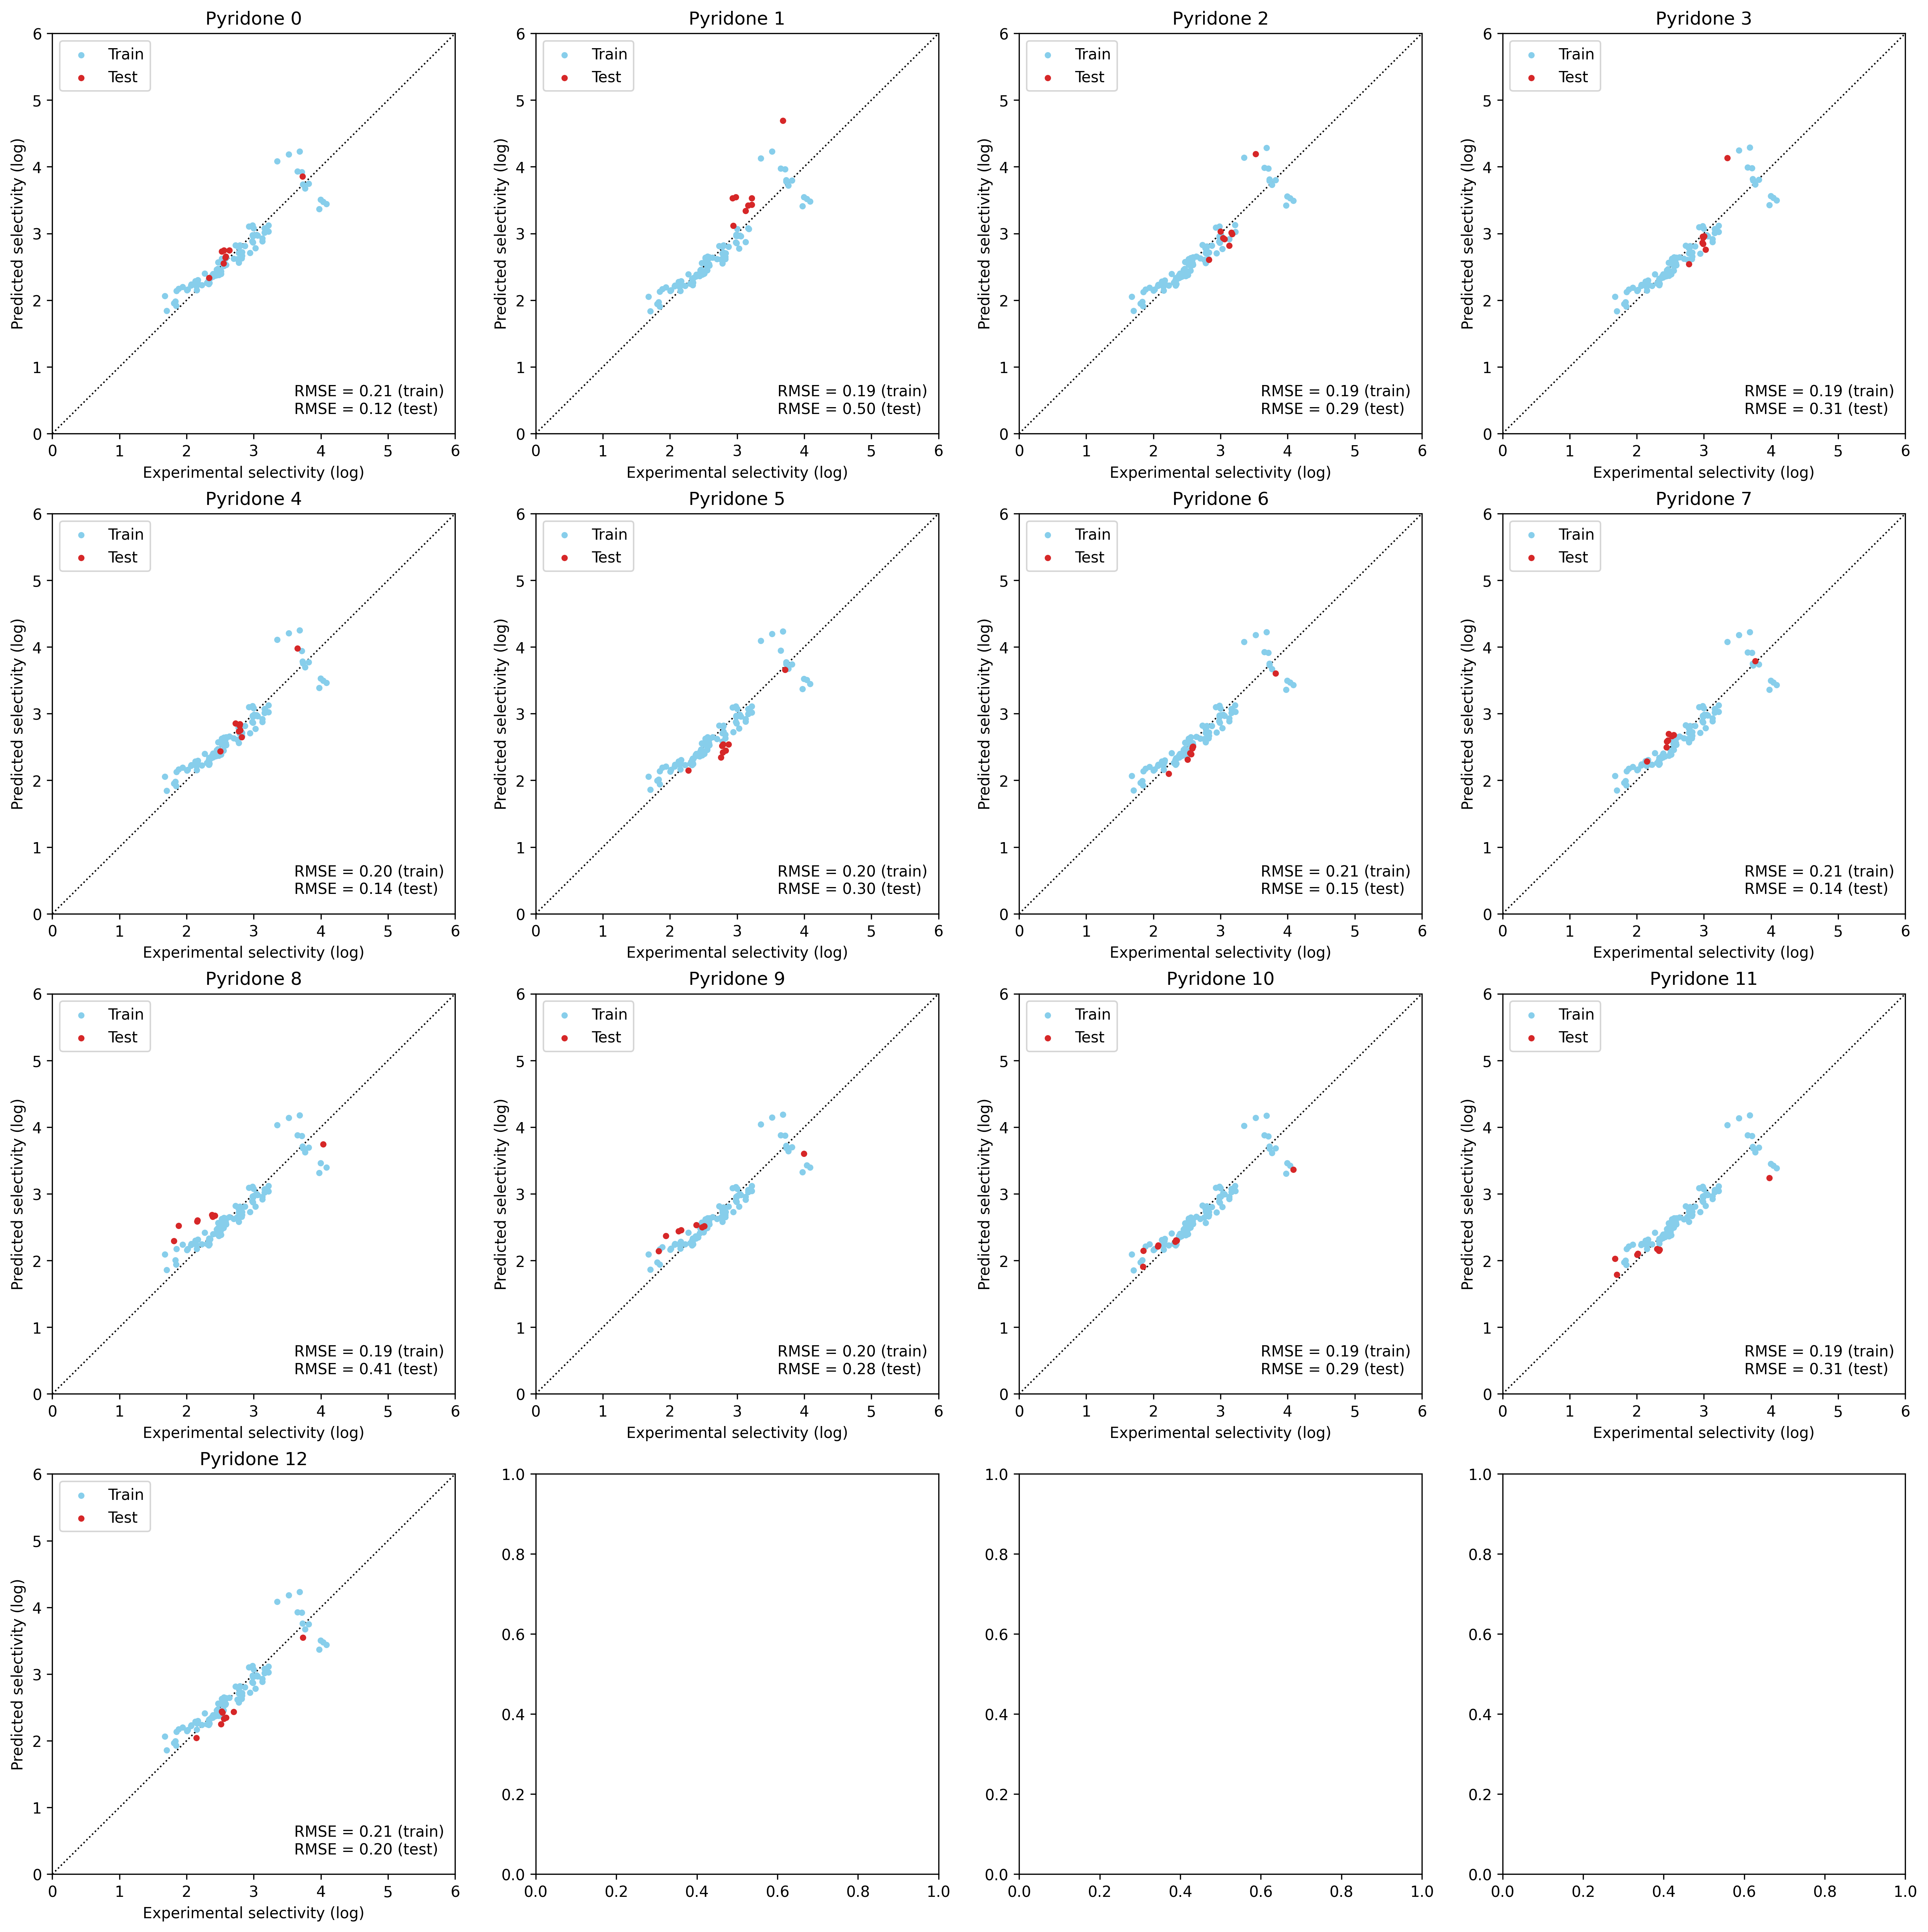

In [27]:
fig, axes = plt.subplots(4, 4, figsize=(22, 22), dpi=300)

for group_test in groups_test:
    df_train_val_min_ = df_train_val_min.filter(pl.col(f'{column_group}_test') == group_test)
    df_test_min_ = df_test_min.filter(pl.col(f'{column_group}_test') == group_test)
    df_train_val_min_rmse_ = df_train_val_min_rmse.filter(pl.col(f'{column_group}_test') == group_test)
    df_test_min_rmse_ = df_test_min_rmse.filter(pl.col(f'{column_group}_test') == group_test)
    
    div, mod = divmod(group_test, 4)
    
    axes[div, mod].plot(
        [0, 100],
        [0, 100],
        c="black",
        linestyle="dotted",
        lw=1,
        zorder=0
    )
    axes[div, mod].scatter(
        df_train_val_min_[column_target],
        df_train_val_min_[column_pred],
        c="skyblue",
        s=10,
        label="Train",
        zorder=1
    )
    axes[div, mod].scatter(
        df_test_min_[column_target],
        df_test_min_[column_pred],
        c="tab:red",
        s=10,
        label="Test",
        zorder=2
    )
    
    axes[div, mod].set_title(f"Pyridone {group_test}")
    axes[div, mod].set_xlabel("Experimental selectivity (log)")
    axes[div, mod].set_ylabel("Predicted selectivity (log)")
    axes[div, mod].set_xlim(0, 6)
    axes[div, mod].set_ylim(0, 6)
    
    axes[div, mod].legend()
    axes[div, mod].text(
        0.60, 0.05,
        f"RMSE = {df_train_val_min_rmse_[f'{column_target}_rmse'][0]:1.2f} (train)\n"
        f"RMSE = {df_test_min_rmse_[f'{column_target}_rmse'][0]:1.2f} (test)",
        transform=axes[div, mod].transAxes
    )
    
plt.savefig(
    f"{file_write}_scatter_each.png",
    transparent=True,
    bbox_inches="tight",
    pad_inches=0.1
)
plt.show()